In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
df = pd.read_csv("/content/mfa_fatigue_dataset.csv")

In [ ]:
df.head(5)

,push_count,avg_interval_seconds,interval_variance,geo_velocity_km,device_mismatch,time_of_day_deviation,label
0,2,8.675466,12.258873,0.260402,1,3.004530,0
1,5,51.988479,30.601903,0.260402,0,0.928694,0
2,1,67.759596,23.239546,0.260402,0,0.142100,0
3,0,73.898700,39.831866,0.260402,0,1.651757,0
4,3,19.502287,13.377436,136.540009,1,6.898612,1


In [ ]:

data = pd.read_csv("mfa_fatigue_dataset.csv")

X = data.drop("label", axis=1)
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# -----------------------
# RULE-BASED BASELINE
# -----------------------
def rule_model(df):
    return ((df["push_count"] > 12) |
            (df["geo_velocity_km"] > 1200)).astype(int)

rule_preds = rule_model(X_test)

In [ ]:
# -----------------------
# LOGISTIC REGRESSION
# -----------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:,1]

In [ ]:
# -----------------------
# RANDOM FOREST
# -----------------------
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced")
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:,1]

In [ ]:
# -----------------------
# EVALUATION FUNCTION
# -----------------------
def evaluate(name, y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    fpr = cm[0][1] / (cm[0][0] + cm[0][1])

    return {
        "Model": name,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "FPR": fpr,
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

In [ ]:
# -----------------------
# COMPARE MODELS
# -----------------------
results = []

results.append(evaluate("Rule-Based", y_test, rule_preds, rule_preds))
results.append(evaluate("Logistic Regression", y_test, lr_preds, lr_probs))
results.append(evaluate("Random Forest", y_test, rf_preds, rf_probs))

results_df = pd.DataFrame(results)
print("\nModel Comparison:\n")
print(results_df)


Model Comparison:

                 Model  Precision    Recall        F1       FPR   ROC-AUC
0           Rule-Based   1.000000  0.516949  0.681564  0.000000  0.758475
1  Logistic Regression   0.833333  0.889831  0.860656  0.011158  0.942830
2        Random Forest   1.000000  0.881356  0.936937  0.000000  0.953671


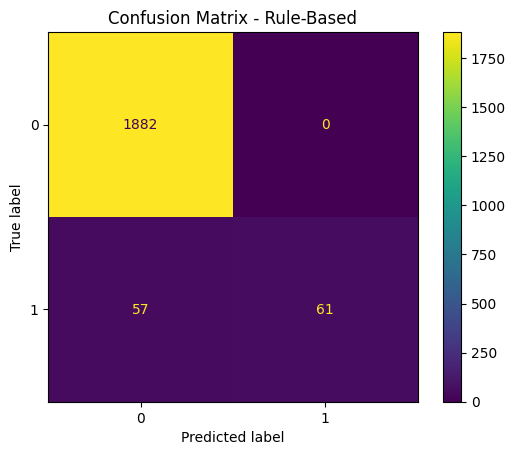

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Rule-based
ConfusionMatrixDisplay.from_predictions(y_test, rule_preds)
plt.title("Confusion Matrix - Rule-Based")
plt.show()

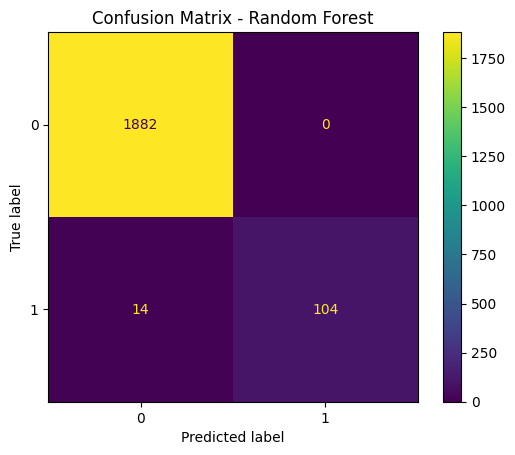

In [ ]:
# Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds)
plt.title("Confusion Matrix - Random Forest")
plt.show()

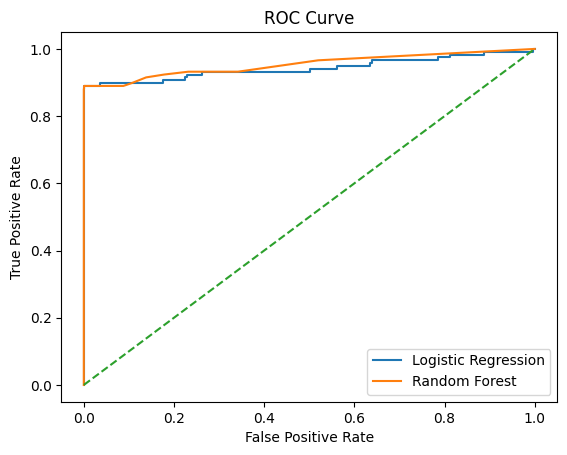

In [ ]:
# -----------------------
# ROC CURVE
# -----------------------
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

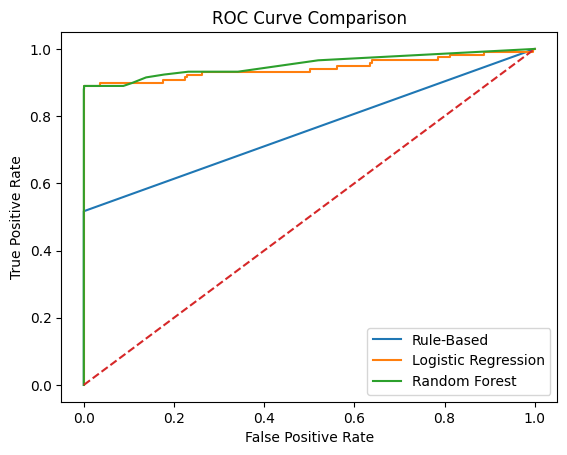

In [ ]:
fpr_rule, tpr_rule, _ = roc_curve(y_test, rule_preds)

plt.figure()
plt.plot(fpr_rule, tpr_rule, label="Rule-Based")
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


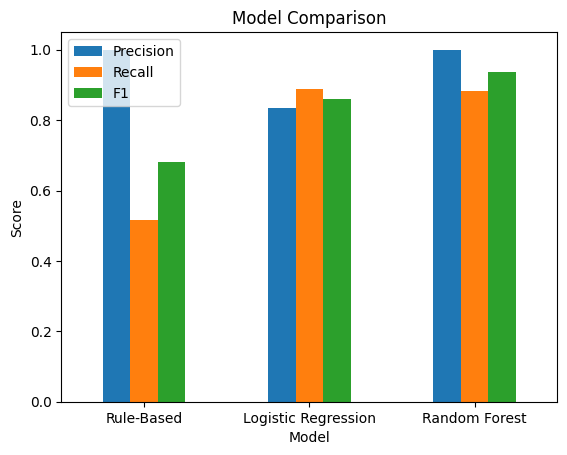

In [ ]:
results_df.set_index("Model")[["Precision","Recall","F1"]].plot(kind="bar")

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()
